In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import random


from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Dense, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils import class_weight
import cv2
import numpy as np
from tqdm import tqdm

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns


In [ ]:
data_images = "dataset_bisindo_merged"

data = []
for label_folder in os.listdir(data_images):
    folder_path = os.path.join(data_images, label_folder)
    if os.path.isdir(folder_path):
        for fname in os.listdir(folder_path):
            img_path = os.path.join(folder_path, fname)
            data.append({'image': img_path, 'class': label_folder})

df_images = pd.DataFrame(data)
df_images.head(10)

,image,class
0,C:/Users/bayyi/OneDrive/Documents/MACHINE LEAR...,A
1,C:/Users/bayyi/OneDrive/Documents/MACHINE LEAR...,A
2,C:/Users/bayyi/OneDrive/Documents/MACHINE LEAR...,A
3,C:/Users/bayyi/OneDrive/Documents/MACHINE LEAR...,A
4,C:/Users/bayyi/OneDrive/Documents/MACHINE LEAR...,A
5,C:/Users/bayyi/OneDrive/Documents/MACHINE LEAR...,A
6,C:/Users/bayyi/OneDrive/Documents/MACHINE LEAR...,A
7,C:/Users/bayyi/OneDrive/Documents/MACHINE LEAR...,A
8,C:/Users/bayyi/OneDrive/Documents/MACHINE LEAR...,A
9,C:/Users/bayyi/OneDrive/Documents/MACHINE LEAR...,A


In [3]:
# Hitung jumlah gambar per kelas
jumlah_per_kelas = df_images['class'].value_counts()
print(jumlah_per_kelas)

class
A    88
B    88
Y    88
X    88
W    88
V    88
U    88
T    88
S    88
R    88
Q    88
P    88
O    88
N    88
M    88
L    88
K    88
J    88
I    88
H    88
G    88
F    88
E    88
D    88
C    88
Z    88
Name: count, dtype: int64


In [4]:
# 80% train, 20% sisa
train_df, test_df = train_test_split(
    df_images,
    test_size=0.2,
    stratify=df_images['class'],
    random_state=42
)

# Dari 20% sisa, bagi 10% val dan 10% test
val_df, test_df = train_test_split(
    test_df,
    test_size=0.5,
    stratify=test_df['class'],
    random_state=42
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 1830, Val: 229, Test: 229


In [5]:
# Data augmentasi untuk training
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)

# Untuk val & test (tanpa augmentasi)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

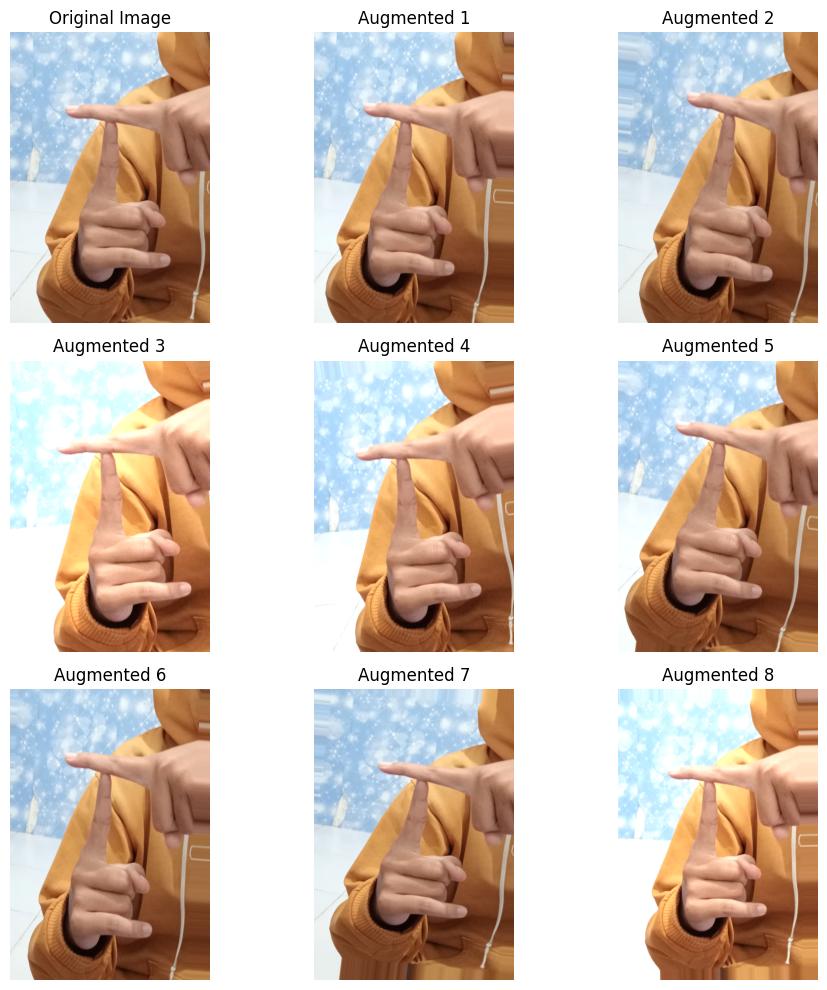

In [6]:
sample_image_path = train_df['image'].iloc[0]
sample_image = cv2.imread(sample_image_path)
sample_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)
sample_image = sample_image.reshape((1,) + sample_image.shape)
plt.figure(figsize=(10, 10))
plt.subplot(3, 3, 1)
plt.imshow(sample_image[0])
plt.title("Original Image")
plt.axis("off")

i = 2
for batch in train_datagen.flow(sample_image, batch_size=1):
    plt.subplot(3, 3, i)
    img_aug = batch[0]
    img_aug = (img_aug - img_aug.min()) / (img_aug.max() - img_aug.min()) * 255
    img_aug = img_aug.astype('uint8')
    plt.imshow(img_aug)
    plt.title(f"Augmented {i-1}")
    plt.axis("off")
    i += 1
    if i > 9:
        break

plt.tight_layout()
plt.show()

In [7]:
# Generator training
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image',
    y_col='class',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    shuffle=True
)

# Generator validasi
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image',
    y_col='class',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

# Generator testing
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image',
    y_col='class',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)


Found 1830 validated image filenames belonging to 26 classes.
Found 229 validated image filenames belonging to 26 classes.
Found 229 validated image filenames belonging to 26 classes.


In [8]:
num_classes = len(train_generator.class_indices)
print(f"Number of classes: {num_classes}")

Number of classes: 26


In [11]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False


model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,217,405 (16.09 MB)

 Trainable params: 4,007,926 (15.29 MB)

 Non-trainable params: 209,479 (818.28 KB)

In [12]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=1,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       
    patience=3,       
    min_lr=1e-6,   
    verbose=1
)

checkpoint = ModelCheckpoint(
    'efficientNet_best_perc7.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [13]:
history = model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=[early_stopping, reduce_lr, checkpoint]
)

c:\Users\bayyi\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0589 - loss: 3.7776
Epoch 1: val_accuracy improved from -inf to 0.18341, saving model to efficientNet_best_perc7.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.0596 - loss: 3.7732 - val_accuracy: 0.1834 - val_loss: 2.9659 - learning_rate: 1.0000e-04
Epoch 2/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2433 - loss: 2.6676
Epoch 2: val_accuracy improved from 0.18341 to 0.53712, saving model to efficientNet_best_perc7.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.2441 - loss: 2.6643 - val_accuracy: 0.5371 - val_loss: 2.1520 - learning_rate: 1.0000e-04
Epoch 3/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4859 - loss: 1.8885
Epoch 3: val_accuracy improved from 0.53712 to 0.76856, saving model to efficientNet_best_perc7.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.4865 - loss: 1.8865 - val_accuracy: 0.7686 - val_loss: 1.3990 - learning_rate: 1.0000e-04
Epoch 4/40
58/58

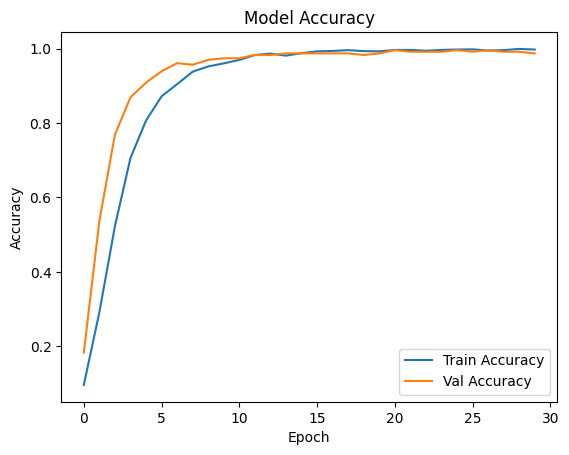

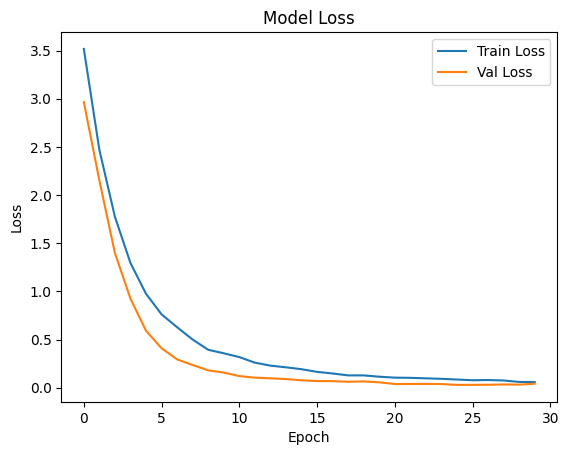

In [14]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [15]:
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Accuracy: {accuracy:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 807ms/step - accuracy: 0.9964 - loss: 0.0317
Validation Accuracy: 0.9956


c:\Users\bayyi\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step


<Figure size 1200x1000 with 0 Axes>

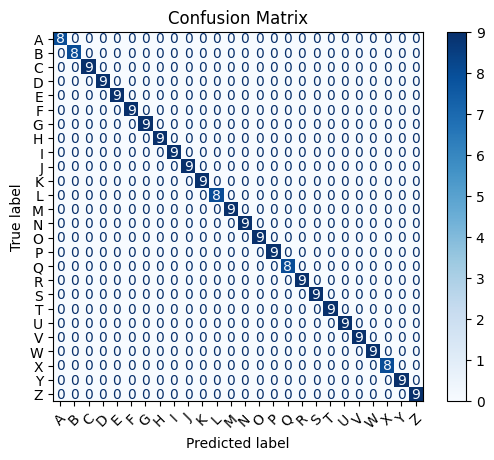

In [17]:
# Predict classes for the test set
y_true = test_df['class'].values
y_pred_probs = model.predict(test_generator)
y_pred = y_pred_probs.argmax(axis=1)
class_labels = list(train_generator.class_indices.keys())
y_pred_labels = [class_labels[i] for i in y_pred]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels, labels=class_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
plt.figure(figsize=(12, 10))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 765ms/step


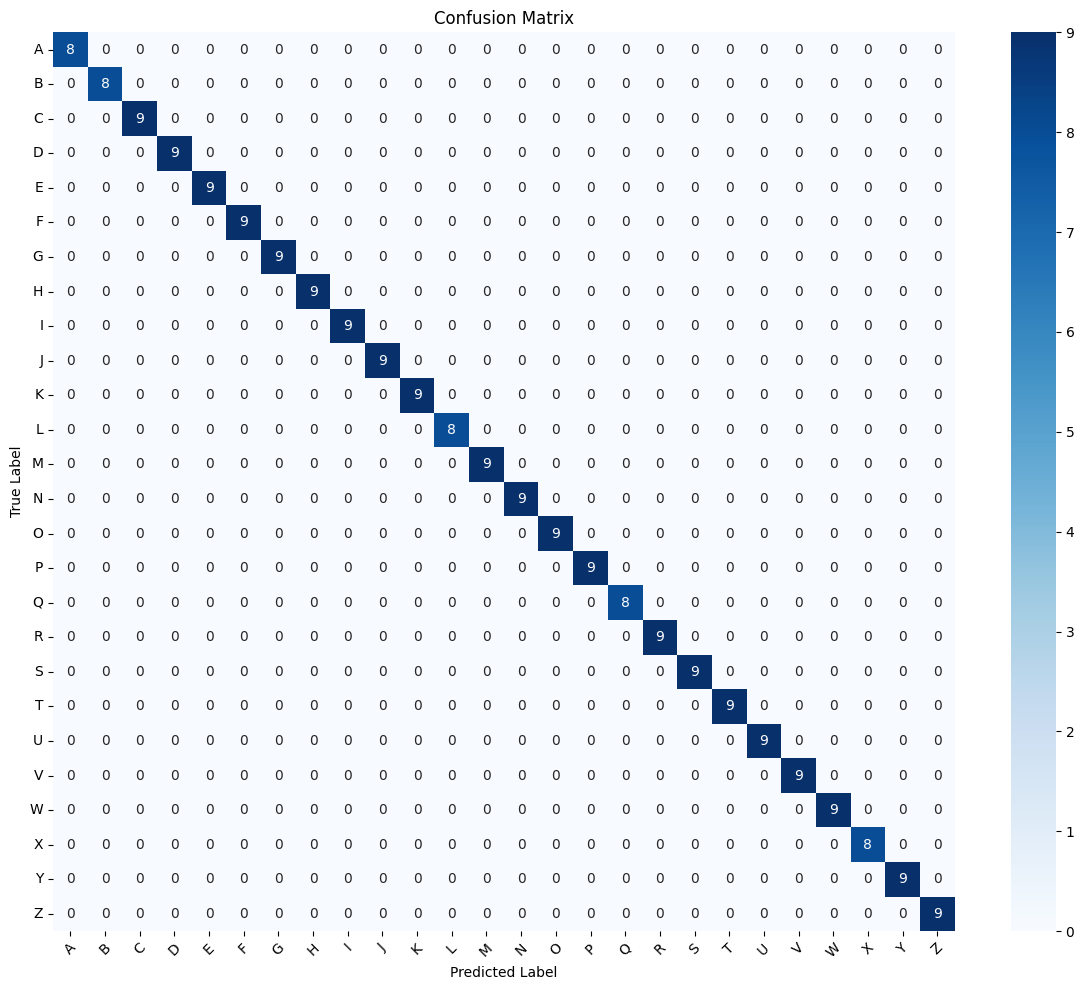

In [ ]:
y_true = test_df['class'].values
y_pred_probs = model.predict(test_generator)
y_pred = y_pred_probs.argmax(axis=1)

class_labels = list(train_generator.class_indices.keys())
y_pred_labels = [class_labels[i] for i in y_pred]

cm = confusion_matrix(y_true, y_pred_labels, labels=class_labels)

# Langkah 3: Visualisasi dengan seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
val_generator.reset()
preds = model.predict(val_generator)
y_pred = np.argmax(preds, axis=1)
y_true = val_generator.classes

all_class_labels = list(val_generator.class_indices.keys())

index_to_label = {v: k for k, v in val_generator.class_indices.items()}
unique_y_true_indices = np.unique(y_true)
filtered_class_labels = [index_to_label[i] for i in unique_y_true_indices]
print(classification_report(y_true, y_pred, target_names=filtered_class_labels, labels=unique_y_true_indices))

8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 730ms/step
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         9
           B       1.00      1.00      1.00         9
           C       1.00      1.00      1.00         9
           D       1.00      1.00      1.00         9
           E       1.00      1.00      1.00         9
           F       1.00      1.00      1.00         8
           G       1.00      1.00      1.00         9
           H       1.00      1.00      1.00         9
           I       0.89      1.00      0.94         8
           J       1.00      1.00      1.00         8
           K       1.00      1.00      1.00         9
           L       1.00      1.00      1.00         9
           M       1.00      1.00      1.00         9
           N       1.00      1.00      1.00         8
           O       1.00      1.00      1.00         9
           P       1.00      1.00      1.00         9
           Q       1.00      1.00      1.0

In [20]:
model.save('efficientNet_best_perc7.h5')